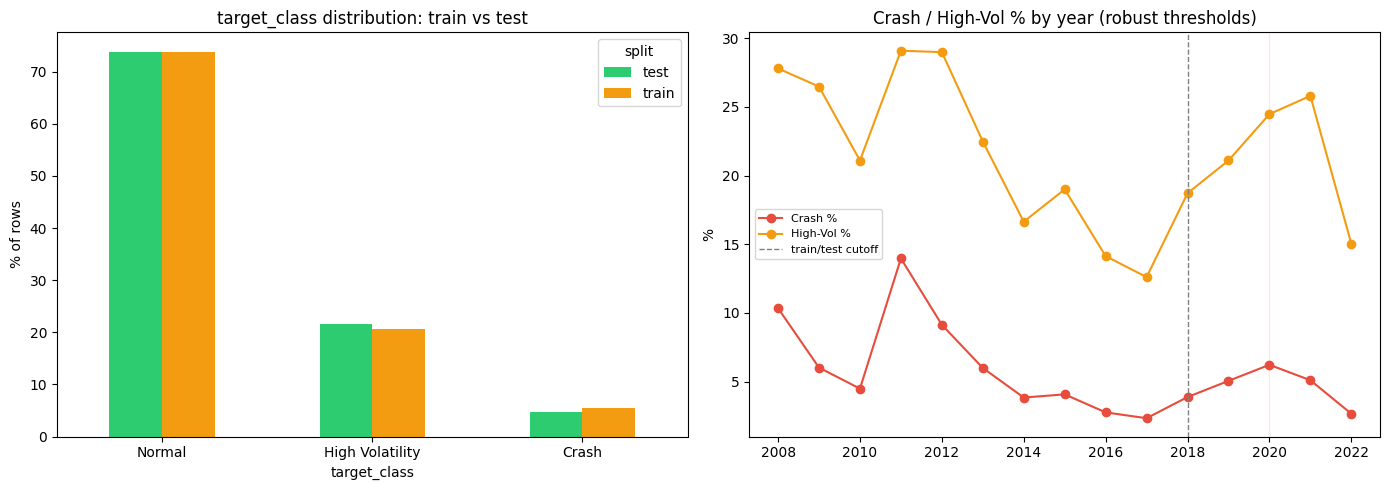

target_class      0     1     3
split                          
test          73.79  21.5  4.71
train         73.83  20.6  5.56


In [13]:
#c0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("dse_final_v3.csv", parse_dates=["date"])

CLASS_LABELS = {0: "Normal", 1: "High Volatility", 3: "Crash"}
CLASS_COLORS = {0: "#2ecc71", 1: "#f39c12", 3: "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dist = df.groupby(["split", "target_class"]).size().unstack(fill_value=0)
dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100
dist_pct[[0, 1, 3]].T.plot(kind="bar", ax=axes[0],
                            color=[CLASS_COLORS[c] for c in [0,1,3]])
axes[0].set_xticklabels([CLASS_LABELS[c] for c in [0,1,3]], rotation=0)
axes[0].set_ylabel("% of rows")
axes[0].set_title("target_class distribution: train vs test")
axes[0].legend(title="split")

yearly = df.groupby([df["date"].dt.year, "target_class"]).size().unstack(fill_value=0)
yearly_pct = yearly.div(yearly.sum(axis=1), axis=0) * 100
axes[1].plot(yearly_pct.index, yearly_pct[3], color=CLASS_COLORS[3], marker="o", label="Crash %")
axes[1].plot(yearly_pct.index, yearly_pct[1], color=CLASS_COLORS[1], marker="o", label="High-Vol %")
axes[1].axvline(2018, color="gray", linestyle="--", linewidth=1, label="train/test cutoff")
axes[1].axvspan(2020, 2020, color="red", alpha=0.1)
axes[1].set_title("Crash / High-Vol % by year (robust thresholds)")
axes[1].set_ylabel("%")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(dist_pct.round(2))

In [ ]:
#c1
CLASS_LABELS = {0: "Normal", 1: "High Volatility", 3: "Crash"}

print("="*70)
print("CLASS-WISE SAMPLE SIZE — target_class (next-day label), v3")
print("="*70)

for split_name in ["train", "test"]:
    subset = df[df["split"] == split_name]
    counts = subset["target_class"].value_counts().sort_index()
    total = len(subset)
    print(f"\n[{split_name.upper()}]  Total rows: {total:,}")
    for cls in [0, 1, 3]:
        n = counts.get(cls, 0)
        pct = n / total * 100
        print(f"  Class {cls} — {CLASS_LABELS[cls]:15s}: {n:>8,}  ({pct:5.2f}%)")

print("\n" + "="*70)
print("OVERALL (train + test combined)")
print("="*70)
overall_counts = df["target_class"].value_counts().sort_index()
overall_total = len(df)
for cls in [0, 1, 3]:
    n = overall_counts.get(cls, 0)
    pct = n / overall_total * 100
    print(f"  Class {cls} — {CLASS_LABELS[cls]:15s}: {n:>8,}  ({pct:5.2f}%)")

summary_table = pd.DataFrame({
    "Train (n)": df[df["split"]=="train"]["target_class"].value_counts().sort_index(),
    "Train (%)": (df[df["split"]=="train"]["target_class"].value_counts(normalize=True).sort_index()*100).round(2),
    "Test (n)":  df[df["split"]=="test"]["target_class"].value_counts().sort_index(),
    "Test (%)":  (df[df["split"]=="test"]["target_class"].value_counts(normalize=True).sort_index()*100).round(2),
})
summary_table.index = summary_table.index.map(CLASS_LABELS)
summary_table.index.name = "Class"
print("\n\nSummary table (paste-ready for paper, Table X):")
print(summary_table)

CLASS-WISE SAMPLE SIZE — target_class (next-day label), v3

[TRAIN]  Total rows: 630,356
  Class 0 — Normal         :  465,423  (73.83%)
  Class 1 — High Volatility:  129,879  (20.60%)
  Class 3 — Crash          :   35,054  ( 5.56%)

[TEST]  Total rows: 294,590
  Class 0 — Normal         :  217,365  (73.79%)
  Class 1 — High Volatility:   63,344  (21.50%)
  Class 3 — Crash          :   13,881  ( 4.71%)

OVERALL (train + test combined)
  Class 0 — Normal         :  682,788  (73.82%)
  Class 1 — High Volatility:  193,223  (20.89%)
  Class 3 — Crash          :   48,935  ( 5.29%)


Summary table (paste-ready for paper, Table X):
                 Train (n)  Train (%)  Test (n)  Test (%)
Class                                                    
Normal              465423      73.83    217365     73.79
High Volatility     129879      20.60     63344     21.50
Crash                35054       5.56     13881      4.71


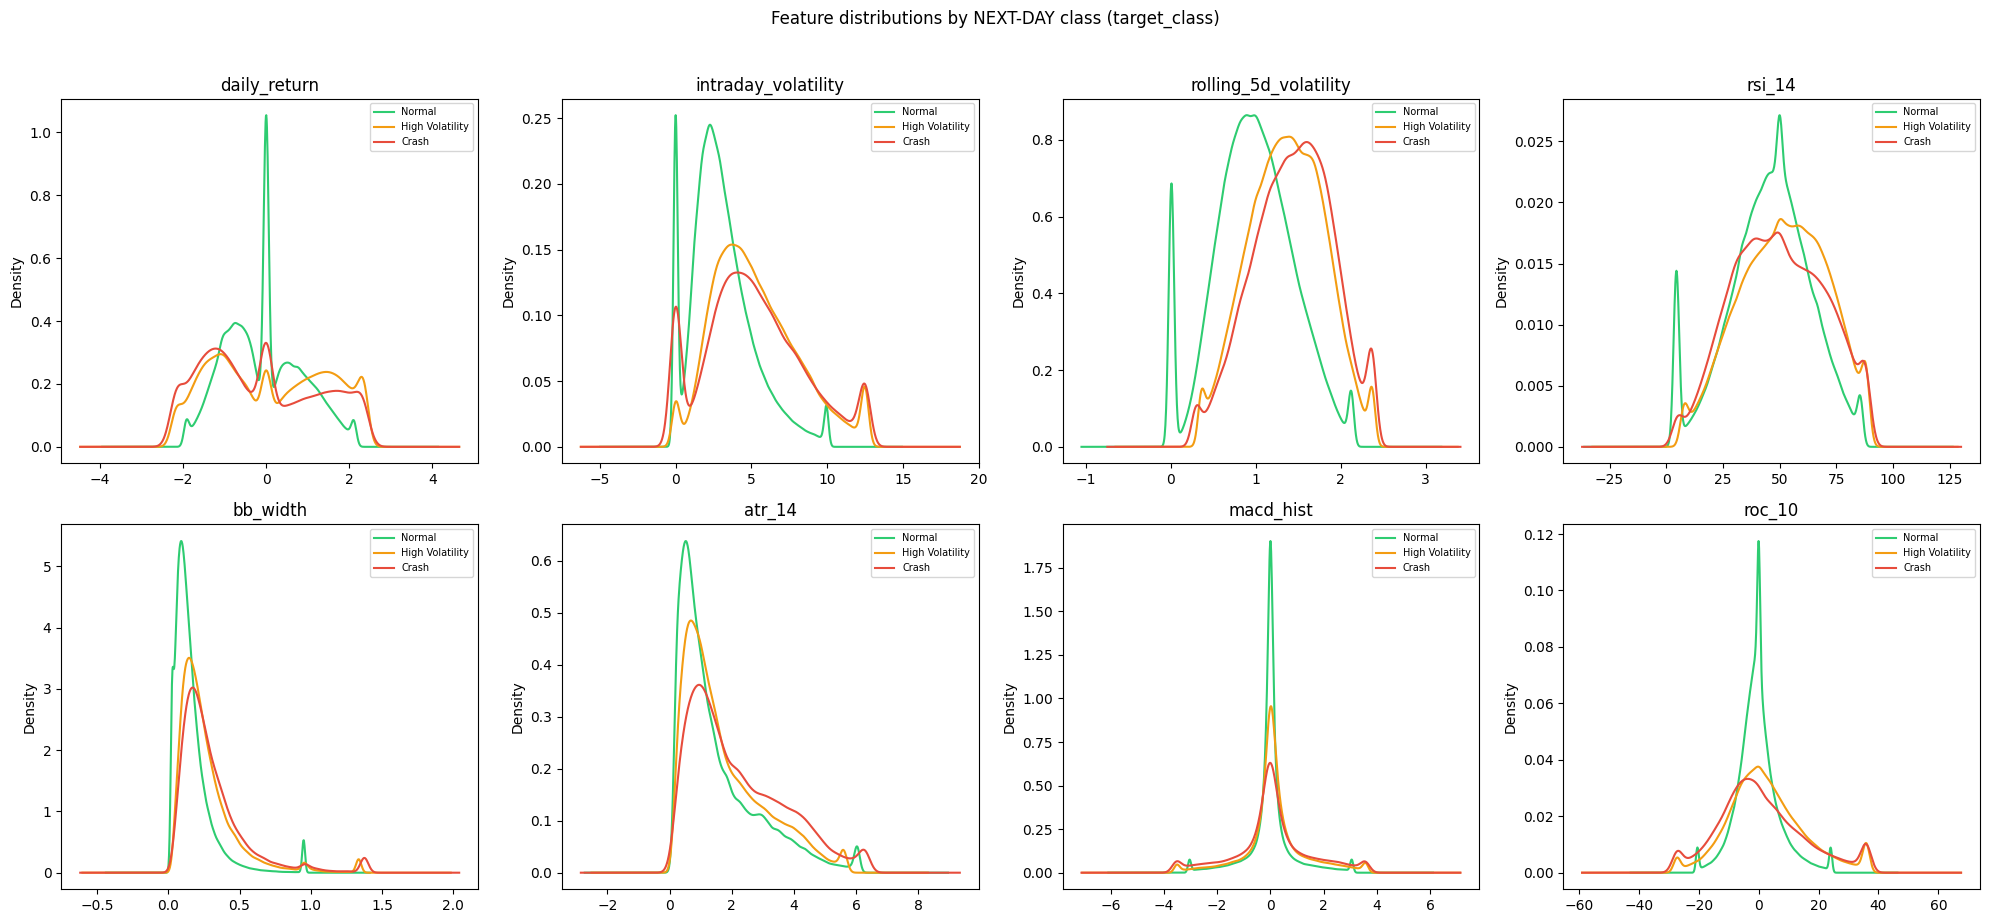

In [10]:
#c2
# Trimmed to v3 ALL_FEATURES — sma_10/sma_20/ema_26/bb_upper/bb_lower dropped (redundant)
FEATURES = ["daily_return","intraday_volatility","rolling_5d_volatility","rsi_14",
            "bb_width","atr_14","macd_hist","roc_10"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for cls in [0, 1, 3]:
        data = df[df["target_class"] == cls][feat].dropna()
        data = data.clip(data.quantile(0.01), data.quantile(0.99))
        data.plot.kde(ax=ax, color=CLASS_COLORS[cls], label=CLASS_LABELS[cls], linewidth=1.5)
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.suptitle("Feature distributions by NEXT-DAY class (target_class)", y=1.02)
plt.tight_layout()
plt.show()

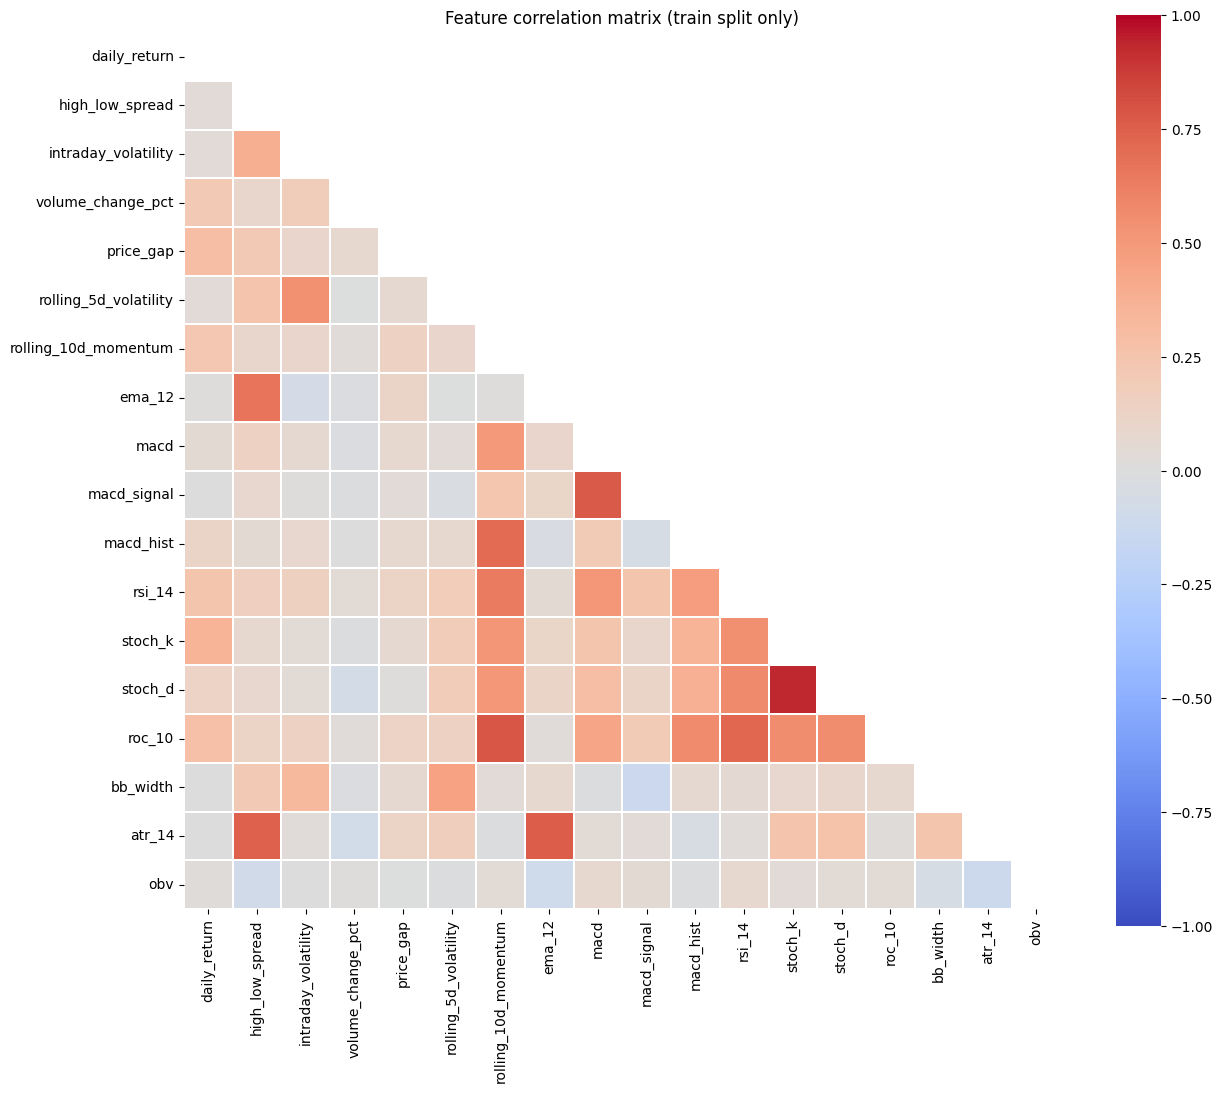

Highly correlated feature pairs remaining (|r| > 0.85):
stoch_k  stoch_d    0.929844
dtype: float64


In [11]:
#c3
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]

corr = df[df["split"]=="train"][ALL_FEATURES].corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, square=True,
            mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title("Feature correlation matrix (train split only)")
plt.tight_layout()
plt.show()

# Should be much shorter than v2's list now — confirms the drop resolved the redundancy
high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
high_corr = high_corr[abs(high_corr) > 0.85].sort_values(key=abs, ascending=False)
print("Highly correlated feature pairs remaining (|r| > 0.85):")
print(high_corr if len(high_corr) else "None — redundancy resolved.")

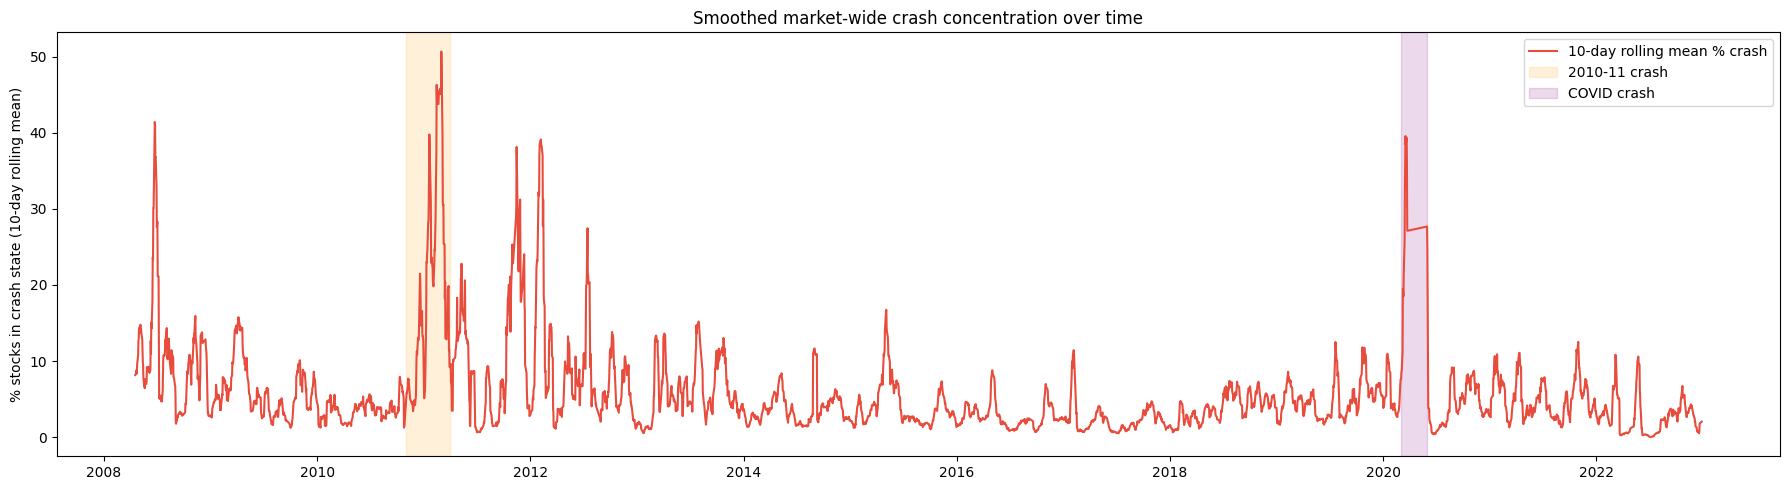

In [12]:
#c4
daily_stats = df.groupby("date").agg(
    pct_crash=("class_same_day", lambda x: (x == 3).mean() * 100),
    pct_high_vol=("class_same_day", lambda x: (x == 1).mean() * 100),
    n_stocks=("trading_code", "nunique"),
)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(daily_stats.index, daily_stats["pct_crash"].rolling(10).mean(),
        color="#e74c3c", label="10-day rolling mean % crash")
ax.axvspan("2010-11-01", "2011-03-31", color="orange", alpha=0.15, label="2010-11 crash")
ax.axvspan("2020-03-01", "2020-05-31", color="purple", alpha=0.15, label="COVID crash")
ax.legend()
ax.set_title("Smoothed market-wide crash concentration over time")
ax.set_ylabel("% stocks in crash state (10-day rolling mean)")
plt.tight_layout()
plt.show()

In [ ]:
#c5
# ─────────────────────────────────────────────
# v3 — confirms the pooled-fallback fix (was the subject of the v2
# diagnostic chain in cells 5-9) and profiles the flagged -100% rows,
# which correspond to suspensions/delistings (Reviewer 4 data-documentation ask)
# ─────────────────────────────────────────────

own = df[~df["_used_pooled_fallback"]]
fb  = df[df["_used_pooled_fallback"]]

print("Crash rate — own-history stocks    :", (own["target_class"]==3).mean()*100, "%")
print("Crash rate — pooled-fallback stocks:", (fb["target_class"]==3).mean()*100, "%  (was 0.00% in v2)")
print(f"\n{fb['trading_code'].nunique()} tickers used pooled fallback:", sorted(fb["trading_code"].unique()))

print("\n" + "="*70)
print("Suspected corporate-action / suspension rows (_suspected_corp_action)")
print("="*70)
flagged = df[df["_suspected_corp_action"]]
print(f"Total flagged rows: {len(flagged):,} ({len(flagged)/len(df)*100:.3f}% of dataset)")
print(f"Unique tickers affected: {flagged['trading_code'].nunique()}")
print("\nValue counts of raw daily_return among flagged rows:")
print(flagged["daily_return"].describe())

# How many flagged rows still ended up correctly labeled crash (target_class==3),
# vs their next-day class — sanity check that suspension days are being
# treated as genuine crash events, not silently dropped or misclassified.
print("\ntarget_class distribution for days AFTER a flagged suspension row "
      "(does a suspension predict next-day crash state?):")
flagged_idx = df.index[df["_suspected_corp_action"]]
next_idx = flagged_idx + 1
next_idx = next_idx[next_idx.isin(df.index)]
print(df.loc[next_idx, "target_class"].value_counts(normalize=True).sort_index())

Crash rate — own-history stocks    : 5.3047112628285085 %
Crash rate — pooled-fallback stocks: 4.112712018967719 %  (was 0.00% in v2)

11 tickers used pooled fallback: ['ADNTEL', 'BDSERVICE', 'COPPERTECH', 'ESQUIRENIT', 'GENEXIL', 'NEWLINE', 'RINGSHINE', 'RUNNERAUTO', 'SEAPEARL', 'SILCOPHL', 'SSSTEEL']

Suspected corporate-action / suspension rows (_suspected_corp_action)
Total flagged rows: 1,353 (0.146% of dataset)
Unique tickers affected: 285

Value counts of raw daily_return among flagged rows:
count    1353.000000
mean       -1.672326
std         1.452410
min        -2.194561
25%        -2.194561
50%        -2.194561
75%        -2.194561
max         2.364048
Name: daily_return, dtype: float64

target_class distribution for days AFTER a flagged suspension row (does a suspension predict next-day crash state?):
target_class
0    0.492979
1    0.245381
3    0.261641
Name: proportion, dtype: float64


In [ ]:
#c6
# Paste-ready summary: mean feature value by class, train split only
summary = df[df["split"]=="train"].groupby("target_class")[ALL_FEATURES].mean().T
summary.columns = [CLASS_LABELS[c] for c in summary.columns]
print("Mean feature value by NEXT-DAY class (train split):")
print(summary.round(3))

Mean feature value by NEXT-DAY class (train split):
                        Normal  High Volatility    Crash
daily_return            -0.074            0.115   -0.123
high_low_spread          1.303            1.835    1.947
intraday_volatility      3.162            5.227    4.999
volume_change_pct       -0.090            0.412   -0.544
price_gap                0.179            0.323    0.279
rolling_5d_volatility    1.027            1.370    1.436
rolling_10d_momentum    -0.173            0.286   -0.139
ema_12                 299.471          327.850  454.015
macd                    -0.122            0.105   -0.189
macd_signal             -0.459           -0.151   -2.985
macd_hist               -0.011            0.171    0.072
rsi_14                  46.780           51.698   49.444
stoch_k                 47.379           54.657   54.883
stoch_d                 47.680           53.644   53.822
roc_10                  -0.438            2.438    0.912
bb_width                 0.179      